# ITRI625 Machine Learning Project

## AI-Based Phishing Email Detection System

### Practical Machine Learning / Deep Learning Implementation

This notebook documents the complete development, training, validation,
testing and evaluation of an AI-based phishing email detection system.

The project includes:

- Dataset exploration
- Data cleaning and preprocessing
- Train, validation and test splitting
- Exploratory data analysis
- Baseline machine learning model
- Deep learning model
- Patience-based early stopping
- Evaluation metric logging
- Accuracy, precision, recall and F1-score
- ROC-AUC analysis
- Precision-Recall analysis
- Confusion matrix
- Training and validation curves
- Explainable Artificial Intelligence (XAI)
- Model export for API integration


In [1]:
import sys
import platform
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import tensorflow as tf

print("=" * 60)
print("ITRI625 PROJECT ENVIRONMENT")
print("=" * 60)
print(f"Python version:       {sys.version}")
print(f"Platform:             {platform.platform()}")
print(f"NumPy version:        {np.__version__}")
print(f"Pandas version:       {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Matplotlib version:   {matplotlib.__version__}")
print(f"TensorFlow version:   {tf.__version__}")
print("=" * 60)
print("\nTensorFlow devices:")
print(tf.config.list_physical_devices())


ITRI625 PROJECT ENVIRONMENT
Python version:       3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]
Platform:             Windows-11-10.0.26200-SP0
NumPy version:        2.5.3
Pandas version:       3.0.6
Scikit-learn version: 1.9.1
Matplotlib version:   3.11.2
TensorFlow version:   2.21.0

TensorFlow devices:


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## 1. Experimental Setup

A fixed random seed is used throughout the experiment to improve
reproducibility and consistency across dataset splitting, model
initialisation and other random operations.


In [2]:
import os
import random

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"Random seed configured: {SEED}")


Random seed configured: 42


## 2. Dataset Acquisition and Initial Inspection

The project uses the publicly available Phishing Email Dataset from Kaggle.

The dataset contains labelled email messages that can be used to train a
binary classification model capable of distinguishing phishing emails from
legitimate emails.

The combined dataset file used in this project is:

`phishing_email.csv`

The target variable represents two classes:

- `0` = Legitimate email
- `1` = Phishing email

Before any preprocessing or model training is performed, the dataset is
inspected for its dimensions, column structure, missing values, duplicate
records and class distribution.


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_PATH = Path("../data/raw/phishing_email.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH.resolve()}\n"
        "Please place phishing_email.csv inside data/raw/"
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Dataset path: {DATA_PATH.resolve()}")


Dataset loaded successfully.
Dataset path: C:\Users\LwaziJunior\OneDrive - CTU Training Solutions (PTY) Ltd\Documents\ITRI 625 Machine Learning Project\ITRI625-Phishing-Email-Detection\data\raw\phishing_email.csv


In [4]:
print("=" * 60)
print("DATASET DIMENSIONS")
print("=" * 60)
print(f"Number of rows:    {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")


DATASET DIMENSIONS
Number of rows:    82,486
Number of columns: 2


In [5]:
print("=" * 60)
print("DATASET COLUMNS")
print("=" * 60)

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")


DATASET COLUMNS
1. text_combined
2. label


In [6]:
df.head()


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [7]:
print("=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df.dtypes)


DATA TYPES
text_combined      str
label            int64
dtype: object


In [8]:
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percent
})

display(missing_summary)


MISSING VALUES


,Missing Values,Percentage
text_combined,0,0.0
label,0,0.0


In [9]:
duplicate_count = df.duplicated().sum()

print("=" * 60)
print("DUPLICATE ANALYSIS")
print("=" * 60)
print(f"Duplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage: {(duplicate_count / len(df)) * 100:.2f}%")


DUPLICATE ANALYSIS
Duplicate rows: 408
Duplicate percentage: 0.49%


In [10]:
print("=" * 60)
print("LABEL DISTRIBUTION")
print("=" * 60)

label_counts = df["label"].value_counts().sort_index()
label_percent = df["label"].value_counts(normalize=True).sort_index() * 100

label_summary = pd.DataFrame({
    "Count": label_counts,
    "Percentage": label_percent
})

display(label_summary)


LABEL DISTRIBUTION


,Count,Percentage
label,,
0,39595,48.002085
1,42891,51.997915


In [11]:
print("Label meaning:")
print("0 = Legitimate email")
print("1 = Phishing email")


Label meaning:
0 = Legitimate email
1 = Phishing email


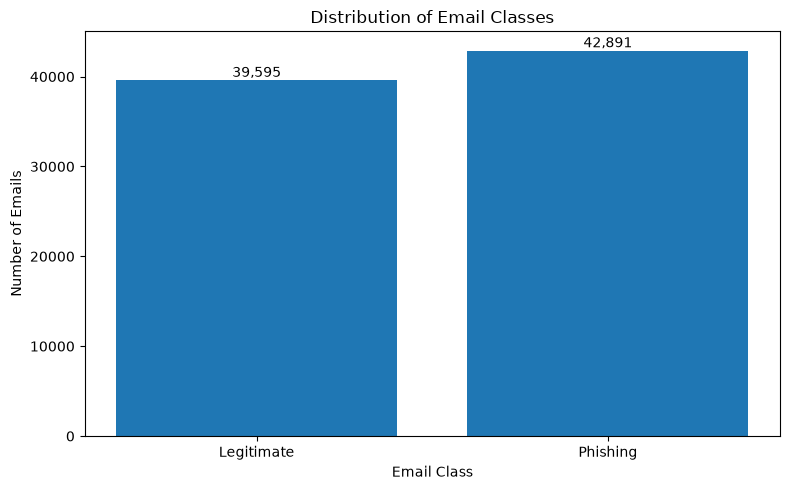

In [12]:
import matplotlib.pyplot as plt

label_names = {
    0: "Legitimate",
    1: "Phishing"
}

plot_counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(
    [label_names.get(i, str(i)) for i in plot_counts.index],
    plot_counts.values
)
plt.title("Distribution of Email Classes")
plt.xlabel("Email Class")
plt.ylabel("Number of Emails")

for i, value in enumerate(plot_counts.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


In [13]:
df["email_length"] = df["text_combined"].astype(str).str.len()

print("=" * 60)
print("EMAIL LENGTH STATISTICS")
print("=" * 60)
display(df["email_length"].describe())


EMAIL LENGTH STATISTICS


count    8.248600e+04
mean     1.288751e+03
std      1.549675e+04
min      1.000000e+00
25%      2.760000e+02
50%      5.580000e+02
75%      1.338000e+03
max      4.279526e+06
Name: email_length, dtype: float64

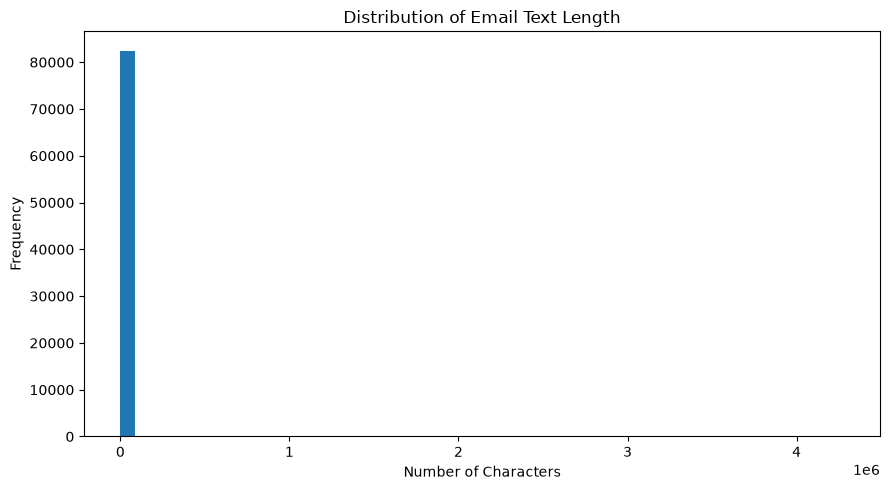

In [14]:
plt.figure(figsize=(9, 5))
plt.hist(
    df["email_length"],
    bins=50
)
plt.title("Distribution of Email Text Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [15]:
legitimate_example = df[df["label"] == 0]["text_combined"].dropna().iloc[0]
phishing_example = df[df["label"] == 1]["text_combined"].dropna().iloc[0]

print("=" * 60)
print("EXAMPLE LEGITIMATE EMAIL")
print("=" * 60)
print(legitimate_example[:1000])

print("\n" + "=" * 60)
print("EXAMPLE PHISHING EMAIL")
print("=" * 60)
print(phishing_example[:1000])


EXAMPLE LEGITIMATE EMAIL
hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls

EXAMPLE PHISHING EMAIL
link dwl g 510 802 11 g wireless pci lan adapter 39 85 39 85 dwl g 510 high speed 2 4 ghz 802 11 g wireless pci lan adapter ieee 802 11 g standardupto 54 mbpsoperating frequency range 2 4 ghz ideal solution enabling wireless networking capabilities desktops pcs home office dwl g 510 visit http www computron com deals link dwl g 510 802 11 g wireless pci lan adapter link g 510 wireless pci adapter featuring latest ieee 802 11 g wireless technology deliverincredibly fast data transfer 2 4 ghz frequency g 510 features 802 11 g standard backwards compatible existing 802 11 11 b products already also offers 64 128 bit wep encryption includes removable antenna driver cd get link g 510 wireless pci lan adapter today general features pci interface removable antenna 64 128 bit wep encryption link act led plug play one stop distributorjebel ali duty free zonedubai uae www computron 

In [16]:
print("=" * 60)
print("DATASET INSPECTION SUMMARY")
print("=" * 60)
print(f"Rows:                  {len(df):,}")
print(f"Columns:               {df.shape[1]}")
print(f"Missing text records:  {df['text_combined'].isnull().sum():,}")
print(f"Missing labels:        {df['label'].isnull().sum():,}")
print(f"Duplicate rows:        {df.duplicated().sum():,}")
print(f"Legitimate emails:     {(df['label'] == 0).sum():,}")
print(f"Phishing emails:       {(df['label'] == 1).sum():,}")


DATASET INSPECTION SUMMARY
Rows:                  82,486
Columns:               3
Missing text records:  0
Missing labels:        0


Duplicate rows:        408
Legitimate emails:     39,595
Phishing emails:       42,891
